In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

## Dataset loading 

In [3]:
# Load the Dataset
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [4]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [5]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [6]:
# Extract year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = movies['year'].astype(float)

# Filter movies
movies_2000 = movies[movies['year'] > 2000]

In [7]:
# Merged the both files with help of movieId
merged = pd.merge(
    ratings,
    movies_2000[['movieId', 'genres']],
    on='movieId',
    how='inner'
)


In [8]:
# Split each genres
merged['genres'] = merged['genres'].str.split('|')
genre_data = merged.explode('genres')

## Dataset View

In [9]:
# print merged
merged

,userId,movieId,rating,timestamp,genres
0,2,6874,4.0,1445714952,"[Action, Crime, Thriller]"
1,2,8798,3.5,1445714960,"[Action, Crime, Drama, Thriller]"
2,2,46970,4.0,1445715013,"[Action, Comedy]"
3,2,48516,4.0,1445715064,"[Crime, Drama, Thriller]"
4,2,58559,4.5,1445715141,"[Action, Crime, Drama, IMAX]"
...,...,...,...,...,...
34980,610,166534,4.0,1493848402,"[Drama, Horror, Thriller]"
34981,610,168248,5.0,1493850091,"[Action, Crime, Thriller]"
34982,610,168250,5.0,1494273047,[Horror]
34983,610,168252,5.0,1493846352,"[Action, Sci-Fi]"


## Data Cleaning

In [10]:
# Remove irrelevant genres from the dataset
remove_genres = ['(no genres listed)', 'Film-Noir']

genre_data = genre_data[~genre_data['genres'].isin(remove_genres)]

## Hierarchical Clustering

In [11]:
# Calculate average rating and total number of ratings for each movie genre
genre_viewer = (
    genre_data
    .groupby('genres')
    .agg(
        Avg_Rating=('rating', 'mean'),
        Rating_Count=('rating', 'count')
    )
    .reset_index()
)

In [12]:
# Print genre_viewer
genre_viewer

,genres,Avg_Rating,Rating_Count
0,Action,3.445008,12320
1,Adventure,3.521113,9970
2,Animation,3.665398,3283
3,Children,3.519980,3053
4,Comedy,3.365287,12779
5,Crime,3.591008,5972
6,Documentary,3.771207,837
7,Drama,3.607859,14468
8,Fantasy,3.528005,5249
9,Horror,3.179671,2307


In [13]:
# Standardize Avg_Rating and Rating_Count by converting them to z-scores
X = genre_viewer[['Avg_Rating', 'Rating_Count']]
X_scaled = (X - X.mean()) / X.std()

In [14]:
# Print the X_scaled
X_scaled

,Avg_Rating,Rating_Count
0,-0.654250,1.490689
1,-0.081648,0.963904
2,1.003919,-0.535079
3,-0.090173,-0.586637
4,-1.254059,1.593580
5,0.444226,0.067697
6,1.800008,-1.083384
7,0.571008,1.972193
8,-0.029794,-0.094373
9,-2.650601,-0.753863


## Apply Hierarchical Clustering

In [15]:
# Perform hierarchical clustering using Ward's method on the standardized data
#Among all hierarchical clustering methods, Ward’s linkage is the most suitable for genre-based viewer behavior analysis 
#due to its variance minimization and balanced clustering.”
Z = linkage(X_scaled, method='ward')

In [16]:
# Print Z
Z

array([[13.        , 14.        ,  0.20073531,  2.        ],
       [10.        , 12.        ,  0.21407035,  2.        ],
       [16.        , 17.        ,  0.2449899 ,  2.        ],
       [ 1.        , 15.        ,  0.44284902,  2.        ],
       [ 3.        ,  8.        ,  0.49595269,  2.        ],
       [ 0.        ,  4.        ,  0.60856958,  2.        ],
       [ 2.        , 19.        ,  0.62374031,  3.        ],
       [ 5.        , 22.        ,  0.74909443,  3.        ],
       [ 6.        , 20.        ,  0.97367698,  3.        ],
       [18.        , 25.        ,  1.04739971,  5.        ],
       [21.        , 23.        ,  1.24805109,  4.        ],
       [11.        , 27.        ,  1.3984607 ,  6.        ],
       [24.        , 26.        ,  1.40802408,  6.        ],
       [ 7.        , 28.        ,  1.77434943,  5.        ],
       [29.        , 30.        ,  3.07651697, 12.        ],
       [ 9.        , 31.        ,  4.02370142,  6.        ],
       [32.        , 33.

## Result

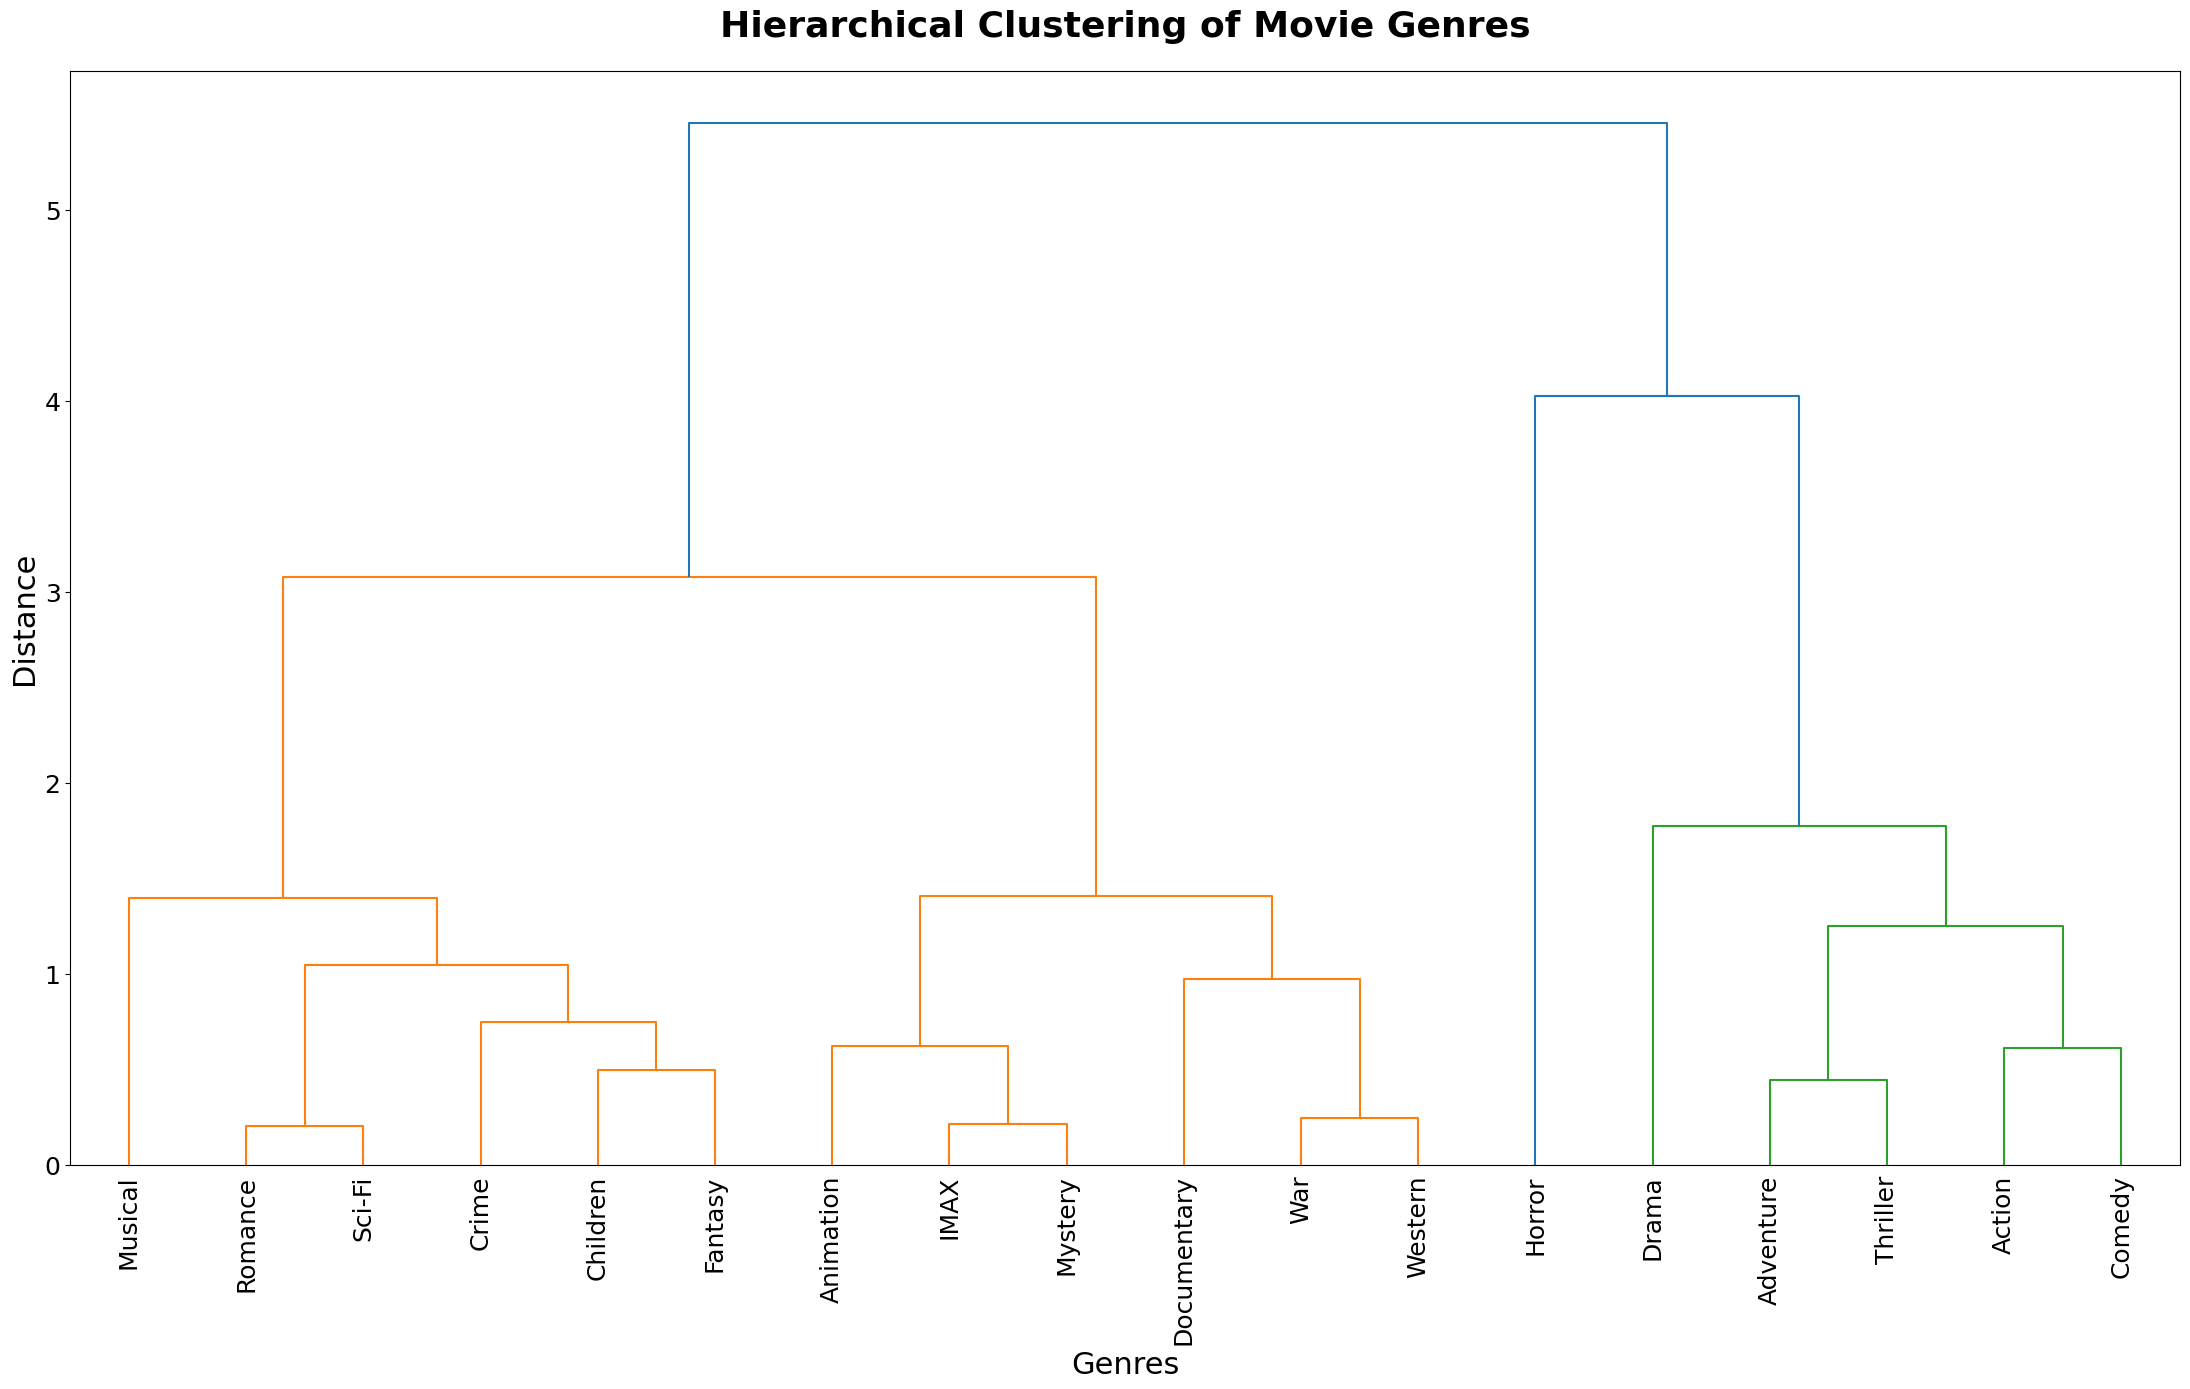

In [17]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# Figure Size
plt.figure(figsize=(22, 14))   

dendrogram(
    Z,
    labels=genre_viewer['genres'].values,
    orientation='top',
    leaf_rotation=90,
    leaf_font_size=16  
)

# Make dendrogram lines thicker
for line in plt.gca().get_lines():
    line.set_linewidth(2.5)     

# Title (extra bold & large)
plt.title(
    "Hierarchical Clustering of Movie Genres",
    fontsize=26,
    fontweight='bold',
    pad=25
)

# Axis labels (large)
plt.xlabel("Genres", fontsize=22)
plt.ylabel("Distance", fontsize=22)

# Tick labels (large)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()

plt.show()


## Conclusion

In this project, we analyzed viewer rating data to understand and group movie genres based on audience behavior using hierarchical clustering. The dataset was prepared by merging movies and ratings files and filtering movies released after the year 2000. Genres such as “no genres listed” and “Film-Noir” were removed to maintain data consistency.

For each genre, viewer behavior was summarized using average rating and rating count. These features were standardized to ensure fair comparison across genres. Hierarchical clustering was then applied using Ward’s linkage method to measure similarity among genres.

The resulting dendrogram revealed clear and meaningful genre groupings. Popular genres such as Action and Comedy showed strong similarity, while Thriller and Adventure formed a close sub-cluster. Family-oriented and niche genres appeared in separate groups, and genres like Horror remained distinct, reflecting unique audience preferences.

Overall, the project demonstrates that hierarchical clustering is an effective approach for identifying relationships among movie genres based on viewer ratings. The insights gained from the dendrogram can support better genre analysis, content organization, and recommendation strategies on movie platforms.